In [35]:
import pyodbc

conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;' 
    'DATABASE=Northwind;'
    'Trusted_Connection=yes;'  
)

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION") 
for row in cursor:
    print(row)

conn.close()


('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tExpress Edition (64-bit) on Windows 10 Pro 10.0 <X64> (Build 22631: )\n',)


<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\2816398157.py:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'


In [36]:
import pandas as pd

def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Northwind;' 
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    query = """
   select * from Orders
where OrderDate = '1997-05-19';
        """   
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
        
        
       print(df)   
    else:
        print("لم يتم العثور على بيانات.")
    
    
    close_connection(conn)


   OrderID CustomerID  EmployeeID  OrderDate RequiredDate ShippedDate  \
0    10540      QUICK           3 1997-05-19   1997-06-16  1997-06-13   
1    10541      HANAR           2 1997-05-19   1997-06-16  1997-05-29   

   ShipVia  Freight       ShipName       ShipAddress        ShipCity  \
0        3  1007.64     QUICK-Stop  Taucherstraße 10       Cunewalde   
1        1    68.65  Hanari Carnes   Rua do Paço, 67  Rio de Janeiro   

  ShipRegion ShipPostalCode ShipCountry  
0        NaN          01307     Germany  
1         RJ      05454-876      Brazil  
تم إغلاق الاتصال بنجاح.


<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1023132926.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1023132926.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


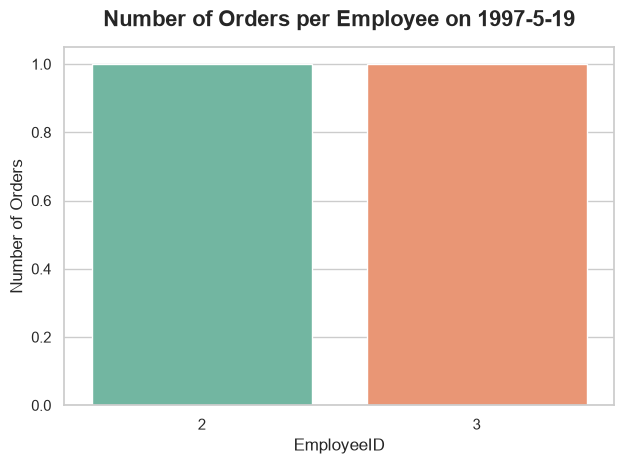

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns= df.columns.str.strip()

plt.Figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

sns.countplot(x="EmployeeID",data=df,hue="EmployeeID",palette="Set2",legend=False)

plt.title("Number of Orders per Employee on 1997-5-19",fontsize=16,fontweight='bold',pad=15)
plt.xlabel("EmployeeID",fontsize=12)
plt.ylabel("Number of Orders",fontsize=12)

plt.tight_layout()
plt.show()

### ❓ Analytical Question:
> **What was the volume and distribution of orders processed by employees on May 19, 1997?**

### 💡 Key Insights:
* The chart shows an extremely low-volume day for the company, with **only two orders** registered in total.
* The workload was distributed evenly, with **Employee 2** and **Employee 3** handling exactly one order each.
*

In [33]:
import pandas as pd

def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Northwind;' 
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    query = """
      SELECT CustomerID,
       COUNT(OrderID) AS TotalOrders
FROM Orders
WHERE OrderDate > '1996-12-31'
GROUP BY CustomerID
HAVING COUNT(OrderID) > 15 ;
        """   
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
        
        
       print(df)   
    else:
        print("لم يتم العثور على بيانات.")
    
    
    close_connection(conn)


  CustomerID  TotalOrders
0      ERNSH           24
1      FOLKO           16
2      HILAA           16
3      QUICK           22
4      SAVEA           28
تم إغلاق الاتصال بنجاح.


<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\640132982.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\640132982.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


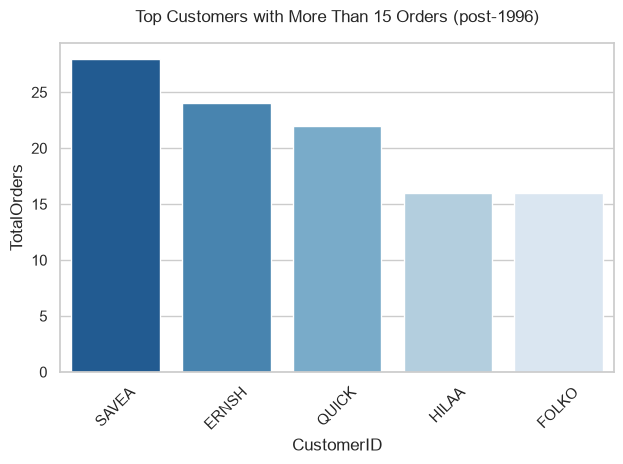

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns= df.columns.str.strip()

df_sorted= df.sort_values(by="TotalOrders",ascending=False)

plt.Figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

sns.barplot(x="CustomerID",y="TotalOrders",data=df_sorted,hue="CustomerID",palette="Blues_r",legend=False)

plt.title("Top Customers with More Than 15 Orders (post-1996)",pad=15)
plt.xlabel("CustomerID",fontsize=12)
plt.ylabel("TotalOrders",fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### ❓ Analytical Question:
> **Who are our most loyal and high-volume (VIP) customers who placed more than 15 orders since the beginning of 1997?**

### 💡 Key Insights:
* The visualization clearly highlights the top-tier customers who drive the highest order volume post-1996.
* **Actionable Recommendation:** We should target these VIP clients with dedicated loyalty programs and exclusive offers to ensure long-term retention.
*

In [18]:
import pandas as pd

def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Northwind;' 
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    query = """
      SELECT Employees.City,
       COUNT(DISTINCT Employees.EmployeeID) AS Employees,
       COUNT(DISTINCT Customers.CustomerID) AS Customers
FROM Employees
LEFT JOIN Customers
ON Employees.City = Customers.City
GROUP BY Employees.City;
        """   
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
        
        
       print(df)   
    else:
        print("لم يتم العثور على بيانات.")
    
    
    close_connection(conn)


       City  Employees  Customers
0  Kirkland          1          1
1    London          4          6
2   Redmond          1          0
3   Seattle          2          1
4    Tacoma          1          0
تم إغلاق الاتصال بنجاح.


<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1511521657.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1511521657.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


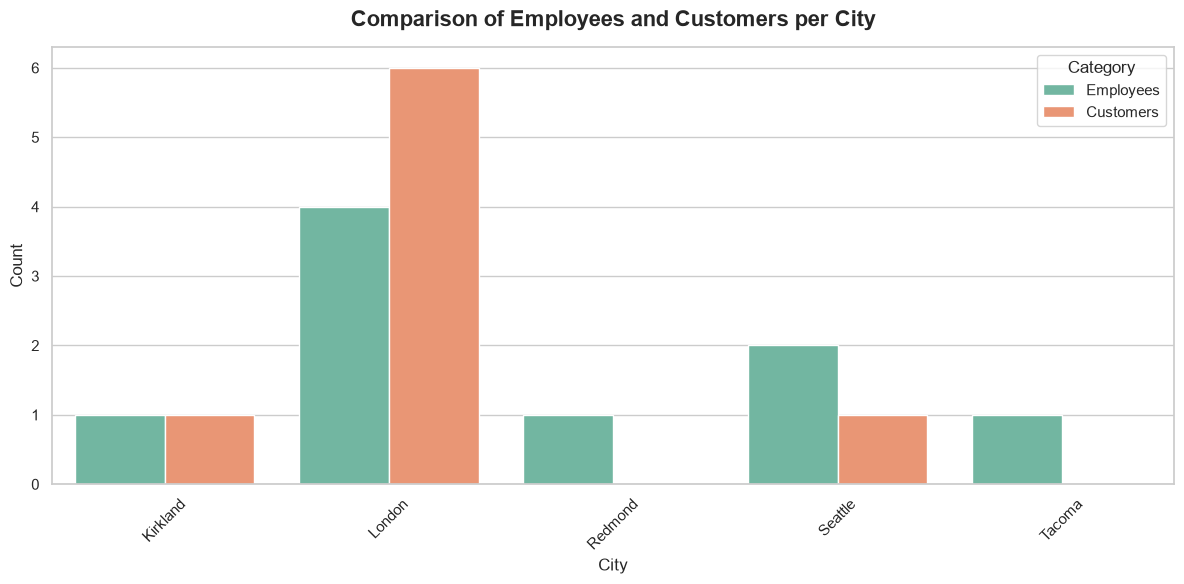

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip() 

df_melted = df.melt(
    id_vars="City", 
    value_vars=["Employees", "Customers"], 
    var_name="Category", 
    value_name="Count"
)


plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x="City", 
    y="Count", 
    hue="Category", 
    data=df_melted, 
    palette="Set2"
)

plt.title("Comparison of Employees and Customers per City", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("City", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### ❓ Analytical Question:
> **How does the geographic distribution of our employees compare to the actual density of our customers across different cities?**

### 💡 Key Insights:
* This dual-comparison plot reveals geographic gaps; some cities have a massive customer base but very few (or no) local employees to support them.
* **Actionable Recommendation:** Management can use this to strategically relocate staff or hire local representatives in high-density customer cities to optimize service.
*

In [31]:
import pandas as pd

def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Northwind;' 
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    query = """
      select top 10 P.ProductName,SUM(od.quantity)AS TotalQuantity
from Products P join [Order Details] od on P.ProductID = od.ProductID
GROUP BY P.ProductName 
ORDER BY TotalQuantity DESC;
        """   
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
        
        
       print(df)   
    else:
        print("لم يتم العثور على بيانات.")
    
    
    close_connection(conn)


              ProductName  TotalQuantity
0       Camembert Pierrot           1577
1    Raclette Courdavault           1496
2       Gorgonzola Telino           1397
3  Gnocchi di nonna Alice           1263
4                 Pavlova           1158
5    Rhönbräu Klosterbier           1155
6      Guaraná Fantástica           1125
7        Boston Crab Meat           1103
8          Tarte au sucre           1083
9                   Chang           1057
تم إغلاق الاتصال بنجاح.


<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\3249804161.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\3249804161.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


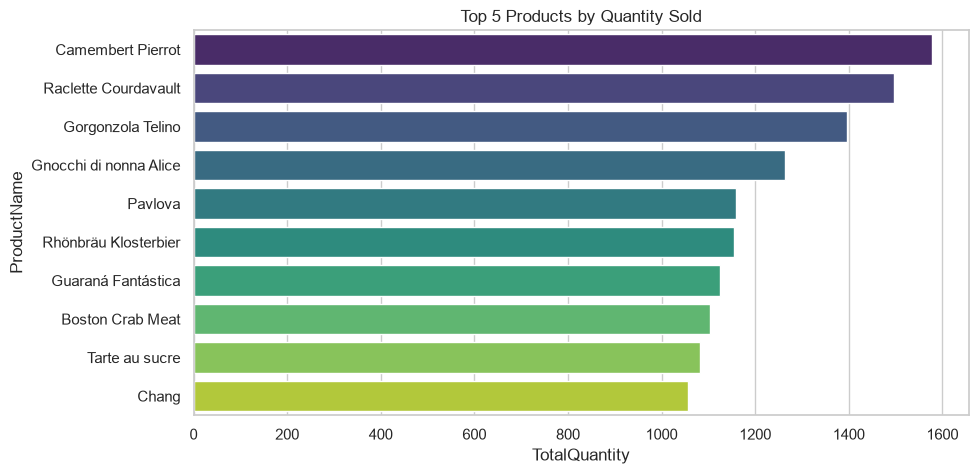

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(10,5))
sns.barplot(x="TotalQuantity",y="ProductName",data=df,hue="ProductName",palette="viridis",legend=False)
plt.title("Top 5 Products by Quantity Sold")
plt.show()

### ❓ Analytical Question:
> **Which are the top 10 products that generated the highest sales volume in terms of total quantity ordered?**

### 💡 Key Insights:
* The chart ranks our most demanded inventory items, with the leading products showing a significant margin over the rest.
* **Actionable Recommendation:** The inventory and procurement teams must ensure a consistent stock level for these top 10 products to prevent any out-of-stock scenarios and maximize revenue.
*

In [28]:
import pandas as pd

def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Northwind;' 
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    query = """
  SELECT Orders.OrderID,
       Employees.FirstName,
       Employees.LastName
FROM Orders
INNER JOIN Employees
ON Orders.EmployeeID = Employees.EmployeeID
WHERE Orders.ShippedDate > Orders.RequiredDate;
        """   
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
        
        
       print(df)   
    else:
        print("لم يتم العثور على بيانات.")
    
    
    close_connection(conn)


    OrderID FirstName   LastName
0     10264   Michael     Suyama
1     10271   Michael     Suyama
2     10280    Andrew     Fuller
3     10302  Margaret    Peacock
4     10309     Janet  Leverling
5     10320    Steven   Buchanan
6     10380     Laura   Callahan
7     10423   Michael     Suyama
8     10427  Margaret    Peacock
9     10433     Janet  Leverling
10    10451  Margaret    Peacock
11    10483    Robert       King
12    10515    Andrew     Fuller
13    10523    Robert       King
14    10545     Laura   Callahan
15    10578  Margaret    Peacock
16    10593    Robert       King
17    10596     Laura   Callahan
18    10660     Laura   Callahan
19    10663    Andrew     Fuller
20    10687      Anne  Dodsworth
21    10705      Anne  Dodsworth
22    10709     Nancy    Davolio
23    10726  Margaret    Peacock
24    10727    Andrew     Fuller
25    10749  Margaret    Peacock
26    10777    Robert       King
27    10779     Janet  Leverling
28    10807  Margaret    Peacock
29    1081

<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1212165482.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_18428\1212165482.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


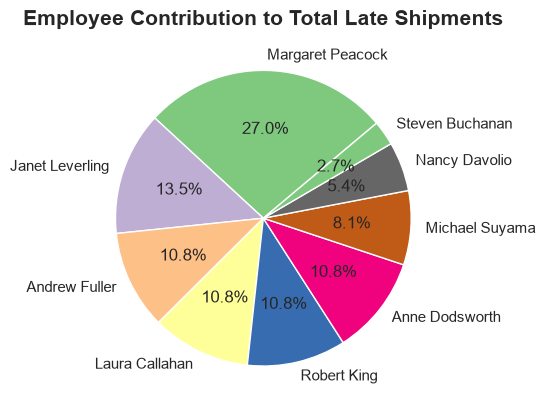

In [29]:
import matplotlib.pyplot as plt

df.columns= df.columns.str.strip()
df['EmployeeName']= df['FirstName']+ ' '+ df['LastName']

df_count=df['EmployeeName'].value_counts()

plt.Figure(figsize=(8,8))
plt.pie(df_count,labels=df_count.index,autopct='%1.1f%%',startangle=40,colors=plt.cm.Accent.colors)

plt.title("Employee Contribution to Total Late Shipments",fontsize=15,fontweight='bold')
plt.show()

### ❓ Analytical Question:
> **Which employees recorded the highest number of late shipments (where Shipped Date exceeded the Required Date)?**

### 💡 Key Insights:
* The visualization pinpoints the team members associated with the highest shipping delays.
* **Actionable Recommendation:** This insight should be used for operational support—identifying bottlenecks in their specific shipping routes or logistics workflows to help them improve efficiency.
